## Import required libraries

In [94]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

## Load a dataset

In [95]:
d=pd.read_csv("house-prices.csv")

## Data preprocessing

In [96]:
d.shape

(128, 8)

In [97]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


Machine Learning models like Linear Regression need numerical values, so you must convert them to int datatype using encoding.

In [98]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

d['Brick'] = le.fit_transform(d['Brick'])
d['Neighborhood'] = le.fit_transform(d['Neighborhood'])

In [99]:
d.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125,0.328125,0.953125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324,0.471376,0.811913
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000,0.000000,0.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000,0.000000,0.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000,0.000000,1.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000,1.000000,2.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000,1.000000,2.000000


In [100]:
d.isnull().sum()

Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64

To check outliers using boxplot

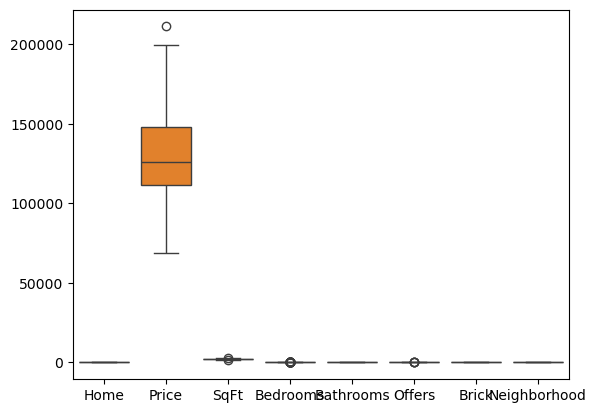

In [126]:
sns.boxplot(data=d)
plt.show()

In [127]:

# remove outliers
Q1 = d['Price'].quantile(0.25)
Q3 = d['Price'].quantile(0.75)

IQR = Q3 - Q1

df = d[(d['Price'] >= Q1 - 1.5*IQR) & (d['Price'] <= Q3 + 1.5*IQR)]

In [128]:
# Calculate Q1 and Q3
Q1 = d.quantile(0.25)
Q3 = d.quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Remove outliers
d_clean = d[~((d < (Q1 - 1.5 * IQR)) | (d > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", d.shape)
print("After Removing Outliers:", d_clean.shape)

Original Shape: (128, 8)
After Removing Outliers: (63, 8)


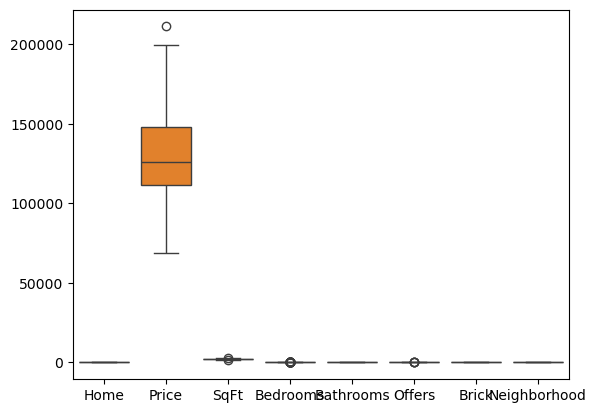

In [129]:
sns.boxplot(data=d)
plt.show()

In [115]:
d.duplicated().sum()

np.int64(0)

<Axes: >

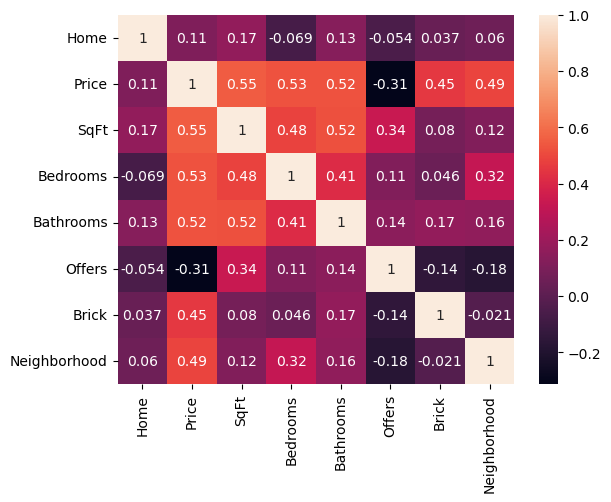

In [116]:
sns.heatmap(d.corr(), annot=True)


In [117]:
d.nunique()

Home            128
Price           123
SqFt             61
Bedrooms          4
Bathrooms         3
Offers            6
Brick             2
Neighborhood      3
dtype: int64

In [118]:
d.corr()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
Home,1.000000,0.108190,0.168553,-0.068568,0.127694,-0.053597,0.037376,0.059871
Price,0.108190,1.000000,0.552982,0.525926,0.523258,-0.313636,0.452817,0.490762
SqFt,0.168553,0.552982,1.000000,0.483807,0.522745,0.336923,0.079792,0.115770
Bedrooms,-0.068568,0.525926,0.483807,1.000000,0.414556,0.114271,0.046380,0.322499
Bathrooms,0.127694,0.523258,0.522745,0.414556,1.000000,0.143793,0.171977,0.163464
Offers,-0.053597,-0.313636,0.336923,0.114271,0.143793,1.000000,-0.144986,-0.177136
Brick,0.037376,0.452817,0.079792,0.046380,0.171977,-0.144986,1.000000,-0.021217
Neighborhood,0.059871,0.490762,0.115770,0.322499,0.163464,-0.177136,-0.021217,1.000000


## train and test splitting

In [119]:
X = d[['SqFt','Bedrooms','Bathrooms']]
y = d['Price']

## Split the Dataset

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Linear Regression Model

In [121]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Make predictions

In [122]:
y_pred = model.predict(X_test)

print("Predicted Prices:\n", y_pred[:5])

Predicted Prices:
 [101653.67332246  95022.06503238 133311.58396858 110357.6592032
 126023.85004097]


## Evlauate the model

In [123]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 14768.459338206874
Mean Squared Error: 320149938.2302679
R2 Score: 0.45681957775488824


## Predict Price for New House

In [124]:
new_house = np.array([[2000,3,2]])

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 123536.9969321844
